In [2]:
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
import numpy as np

A=np.array([
        [(6.0 - np.sqrt(6))/5, (6.0 + np.sqrt(6))/5],
        [(12.0 - 7.0*np.sqrt(6.0))/25.0, (12.0 + 7*np.sqrt(6.0))/25.0]
    ], np.double)
np.set_printoptions(precision=16)
b = np.array([2.0, 2/3], np.double)
print(np.linalg.solve(A,b))


[1.0249716523768428 0.7528061254009346]


In [3]:
def parametric(x1, y1, x2, y2, t):
    return x1 + (x2-x1)*t, y1 + (y2-y1)*t

def curve_2d_order(ax, ay, bx, by, px, py, t):
    M = parametric(ax, ay, px, py, t) # M(x,y)
    N = parametric(px, py, bx, by, t)
    return parametric(M[0], M[1], N[0], N[1], t)

def curve_3d_order(ax, ay, bx, by, p1x, p1y, p2x, p2y, t):
    M = curve_2d_order(ax, ay, bx, by, p1x, p1y, t)
    N = curve_2d_order(ax, ay, bx, by, p2x, p2y, t)
    return  parametric(M[0], M[1], N[0], N[1], t)

def curve_4d_order(ax, ay, bx, by, p1x, p1y, p2x, p2y, p3x, p3y, t):
    M = curve_3d_order(ax, ay, bx, by, p1x, p1y, p2x, p2y, t)
    N = curve_3d_order(ax, ay, bx, by, p2x, p2y, p3x, p3y, t)
    return  parametric(M[0], M[1], N[0], N[1], t)


In [3]:
def genetic(par1, par2, N, gen):
    def plus(array1, array2, N):
        array2 = list(array2)
        array3 = []
        for i in range(N):
            array3.append(array1[i] + array2[i])
        return array3

    def get_pot(cord, c1, c2, h, pot, p):
        buff = list(c1)
        buff[cord] += h
        if choices([1, 0], weights=[25, 75]):
            if p=='y':
                k1 = choices([-1, 1], weights=[75, 25])
                buff = plus(buff, k1*np.random.normal(0.25, 0.05, N), N)
            elif p == "x":
                buff = plus(buff, np.random.normal(0, 0.15, N), N)
        pot.append(buff)
        buff = list(c2)
        buff[cord] -= h
        if choices([1, 0], weights=[25, 75]):
            if p=='y':
                k1 = choices([-1, 1], weights=[50, 50])
                buff = plus(buff, k1*np.random.normal(0.25, 0.05, N), N)
            elif p == "x":
                buff = plus(buff, np.random.normal(0., 0.15, N), N)

        pot.append(buff)


    def set_cord(cord, c1, c2, h):
        c1[cord] += h
        c2[cord] -= h

    #Хромосомный набор родителей
    cx1, cx2 = par1[0], par2[0]
    cyu1, cyu2  = par1[1], par2[1]
    cyl1, cyl2 = par1[2], par2[2]

    #Процесс эволюции
    for i in range(gen):
        #Хромосомные наборы возможных потомков
        potx = []
        potyu = []
        potyl = []
        potx_n = []
        potyl_n = []
        potyu_n = []
        potx_n.append(list(cx1))
        potx_n.append(cx2)
        potyu_n.append(cyu1)
        potyu_n.append(cyu2)
        potyl_n.append(cyl1)
        potyl_n.append(cyl2)
        kat = [] #Качества потомков
        #Рождение и мутация потомков
        hx = cx2 - cx1
        hyu = cyu2 - cyu1
        hyl = cyl2 - cyl1
        for i in range(1,N):
            for j in range(i, N):
                get_pot(j, cx1, cx2, hx[j], potx, 'x')
                get_pot(j, cyl1, cyl2, hyl[j], potyl, 'y')
                get_pot(j, cyu1, cyu2, hyu[j], potyu, 'y')
                #(potx[0])
            set_cord(i, cx1, cx2, hx[i])
            set_cord(i, cyl1, cyl2, hyl[i])
            set_cord(i, cyu1, cyu2, hyu[i])
        #Убийство уродов
        print(len(potx))
        potx_n = []
        potyl_n = []
        potyu_n = []
        count = 2
        for i in range(len(potx)):
            logic = 1
            prev = potx[i][0]
            for j in potx[i]:
                if j < prev:
                    logic = 0
                    break
                else:
                    prev = j
            if logic == 1:
                potx_n.append(potx[i])
                potyl_n.append(potyl[i])
                potyu_n.append(potyu[i])
                count += 1

        #Рассчёт и отбор 2 наилучших
        for i in range(len(potx_n)):
            kat.append(k(potx_n[i], potyu_n[i], potyl_n[i]))

        #Новые родители
        if kat == []:
            return "Convergence error"
        else:
            kad = min(kat)
            ind = kat.index(kad)
            kat.pop(ind)
            cx1 = potx_n[ind]
            cyu1 = potyu_n[ind]
            cyl1 = potyl_n[ind]
            potx_n.pop(ind)
            potyu_n.pop(ind)
            potyl_n.pop(ind)
            print("1", 1.0/kad, cx1, cyl1, cyu1)

            kad = min(kat)
            ind = kat.index(kad)
            cx2 = potx_n[ind]
            cyu2 = potyu_n[ind]
            cyl2 = potyl_n[ind]
            print("2", 1.0/kad, cx2, cyl2, cyu2)
    return None


#px3 = [0.15, 0.32, 0.6, 0.8, 0.9]
#py3 = [-0.11200318, 0.01210229, 0.05873861, 0.29846013, 0.1100635]
#qy3 = [0.38190633, 0.4607554, 0.4526208, 0.09432811, 0.21223437]

#px4 = [0.15, 0.32, 0.6,  0.8,  0.9]
#py4 = [-0.17685708, -0.01412248, -0.16502327, 0.2545887, 0.00129665]
#qy4 = [0.25515416,  0.3613079, 0.37641853, -0.03741787, 0.12838295]

#par1 = np.array([px4, py4, qy4])
#par2 = np.array([px3, py3, qy3])
#genetic(par1, par2, 5, 10)
#print(np.random.normal(0.0, 0.1, 5))

In [4]:
def draw(ax, ay, p1x, p1y, p3x, p3y, bx, by, N):
    x_axis = []
    y_axis = []
    h = 1/N
    for i in range(N+1):
        #doker = curve_4d_order(ax, ay, bx, by, p1x, p1y, p2x, p2y, p3x, p3y, h*i)
        doker = curve_3d_order(ax, ay, bx, by, p1x, p1y, p3x, p3y, h*i)
        x_axis.append(doker[0])
        y_axis.append(doker[1])
    plt.plot(x_axis, y_axis)
    #plt.scatter([ax, bx, p1x, p3x], [ay, by, p1y, p3y])


In [5]:
def get_coeff(p0, p01, p1, p2, p22, p3, p):
    A=[
        [1.0, 1.0, 0.0, 0.0],
        [-2.0, 2.0, -1.0, 0.0],
        [0.0, 0.0, 1.0, 1.0],
        [0.0, 1.0, -2.0, 2.0]
    ]
    for i in range(p):
        for j in range(p):
            pass
    b = [2.0*p1, -1.0*p01, 2.0*p2, p22]
    x = np.linalg.solve(A, b)

    res = [p0, p01, x[0], p1, x[1], x[2], p2, x[3], p22, p3]
    return res

def spline(x_c, y_c):
    draw(x_c[0], y_c[0], x_c[1], y_c[1], x_c[2], y_c[2], x_c[3], y_c[3], 100)
    draw(x_c[3], y_c[3], x_c[4], y_c[4], x_c[5], y_c[5], x_c[6], y_c[6], 100)
    draw(x_c[6], y_c[6], x_c[7], y_c[7], x_c[8], y_c[8], x_c[9], y_c[9], 100)

[0.0, 0.03, 0.30066666666666664, 0.5, 0.6993333333333334, 0.8273333333333335, 0.9, 0.9726666666666668, 0.99, 1.0]
[0.0, 0.08, 0.0842, 0.075, 0.0658, 0.0432, 0.023, 0.0028000000000000026, -0.015, 0.0]


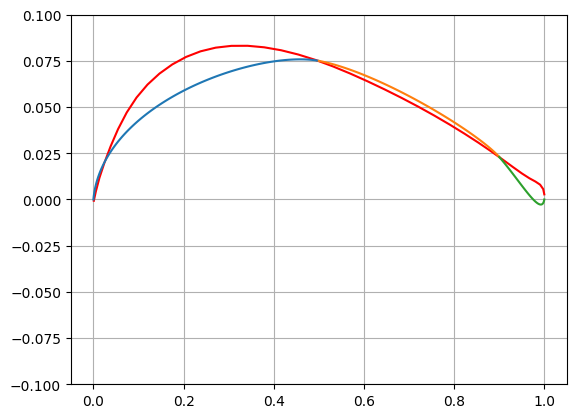

In [16]:
with open("inp.txt") as f:
    x, yb, yn = [], [], []
    for i in f:
        enter = i.split()
        x.append(float(enter[0]))
        yb.append(float(enter[1]))
        yn.append(float(enter[2]))

#Фиксированы
x0, y0 = 0.0, 0.0
x3, y3 = 1.0, 0.0

#Меняются
x01, y01 = 0.03, 0.08
x1, y1 = 0.5, 0.075
x2, y2 = 0.9, 0.023
x22, y22 = 0.99, -0.015

#p1x, p1y = 0.16, 0.21
#p2x, p2y = 0.39, 0.18
#p3x, p3y = 1.0, 0.04

#q1x, q1y = p1x, -p1y
#q2x, q2y = 0.39, -0.106
#q3x, q3y = 0.45, -0.105

coords1 = get_coeff(x0, x01, x1, x2, x22, x3, 1)
#coords1 = [0.0, 0.2, 0.485, 0.9, 0.9, 0.9, 0.9, 0.97, 1.0, 1.0]
#coords2 = [0.0, 0.22, 0.085, 0.0235, 0.0235, 0.0235, 0.0235, 0.010, 0.015, 0.0]
coords2 = get_coeff(y0, y01, y1, y2, y22, y3, 0)
print(coords1)
print(coords2)


plt.xlim(-0.05, 1.05)
plt.ylim(-0.1, 0.10)
plt.plot(x, yb, 'r')
#plt.plot(x, yn, 'r')
spline(coords1, coords2)
plt.grid()